In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
train = pd.read_csv(r'D:\churn prediction\data\raw\raw_train.csv')
test = pd.read_csv(r'D:\churn prediction\data\raw\raw_test.csv')

In [3]:
import os
os.chdir(r"D:\churn prediction")

In [4]:
from src.components.module_02_feature_engineering import FeatureEngineer
from src.utils.main_utils import read_config_file

cfg = read_config_file()

    
fe = FeatureEngineer(cfg)

2026-06-02 20:23:14,421 - main_utils.py - INFO - Yaml file load from src/config/config_yaml.yaml succesfully


In [5]:
train = fe.create_features(train)
test = fe.create_features(test)

2026-06-02 20:23:54,562 - module_02_feature_engineering.py - INFO - Creating new features
2026-06-02 20:23:54,581 - module_02_feature_engineering.py - INFO - Feature creation completed
2026-06-02 20:23:54,583 - module_02_feature_engineering.py - INFO - Creating new features
2026-06-02 20:23:54,593 - module_02_feature_engineering.py - INFO - Feature creation completed


<Axes: >

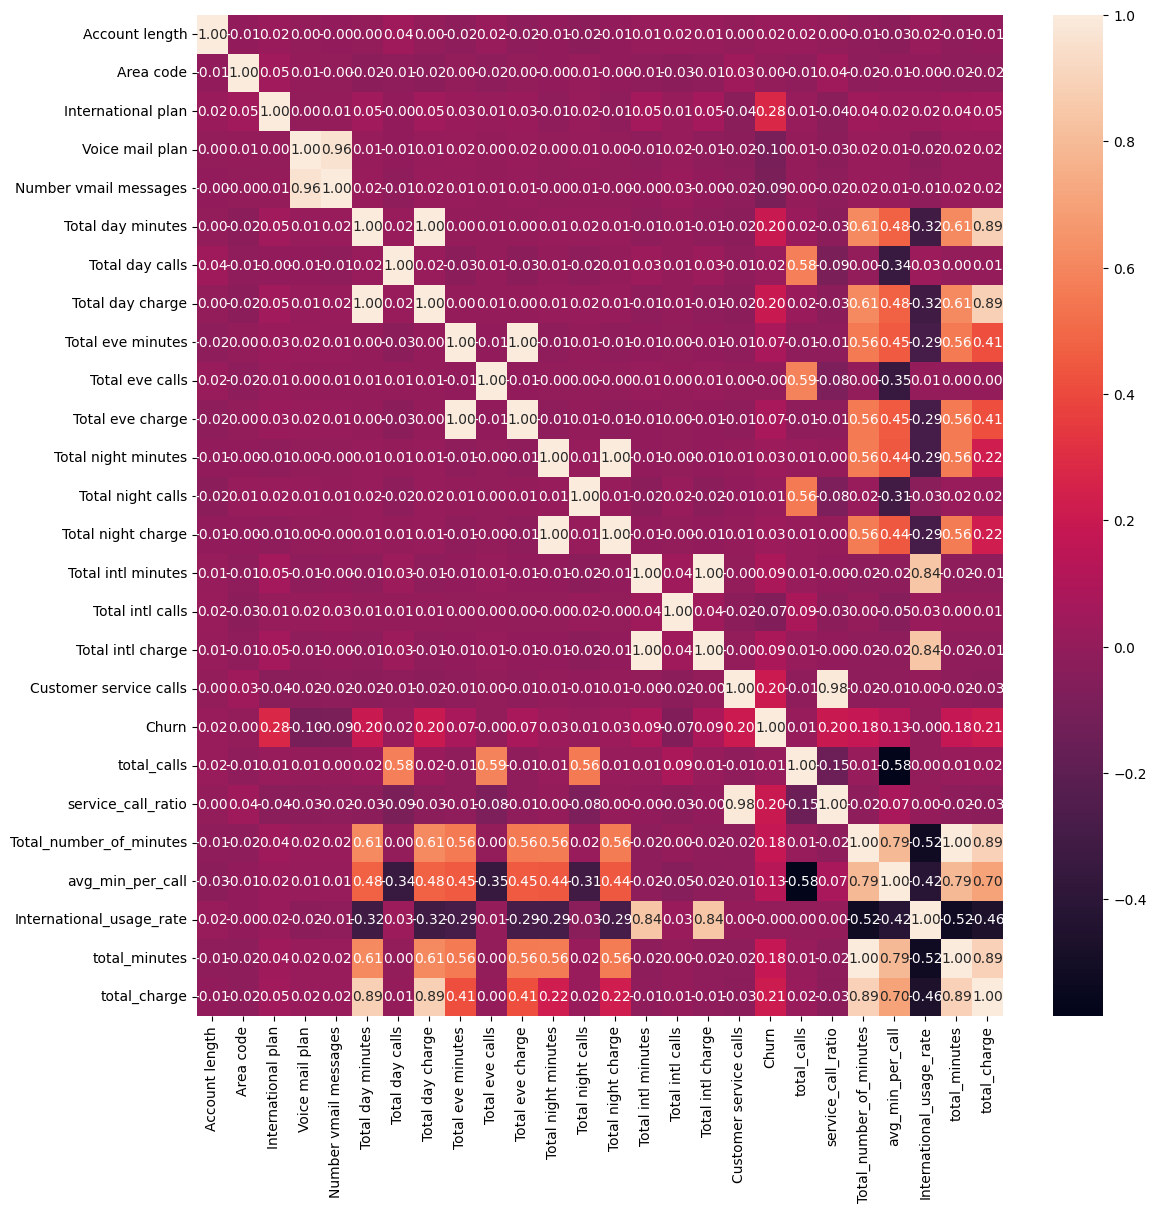

In [6]:
#checking multicollinearity
plt.figure(figsize=(13,13))
sns.heatmap(train.select_dtypes([int,float]).corr(),annot=True,fmt='0.2f')

adding new features has caused the multicollinearity in data ! so we need to remove some features! so it will not affect the feature importance!

In [9]:
X_train = train.drop(columns = 'Churn')
y_train = train['Churn']

In [10]:
train ,drop_feature = fe.remove_multicollinear_feature(train,y_train,0.70)


2026-06-02 20:25:47,695 - module_02_feature_engineering.py - INFO - Checking for highly correlated features
2026-06-02 20:25:47,703 - module_02_feature_engineering.py - INFO - GROUP  : ['Voice mail plan', 'Number vmail messages']
2026-06-02 20:25:47,703 - module_02_feature_engineering.py - INFO - KEEP   : Voice mail plan (target corr: 0.0993)
2026-06-02 20:25:47,721 - module_02_feature_engineering.py - INFO - DROP   : {'Number vmail messages': np.float64(0.0865)}
2026-06-02 20:25:47,723 - module_02_feature_engineering.py - INFO - GROUP  : ['Total_number_of_minutes', 'total_minutes', 'Total day charge', 'Total day minutes', 'total_charge', 'avg_min_per_call']
2026-06-02 20:25:47,725 - module_02_feature_engineering.py - INFO - KEEP   : total_charge (target corr: 0.2098)
2026-06-02 20:25:47,727 - module_02_feature_engineering.py - INFO - DROP   : {'Total_number_of_minutes': np.float64(0.1777), 'total_minutes': np.float64(0.1777), 'Total day charge': np.float64(0.1957), 'Total day minutes'

<Axes: >

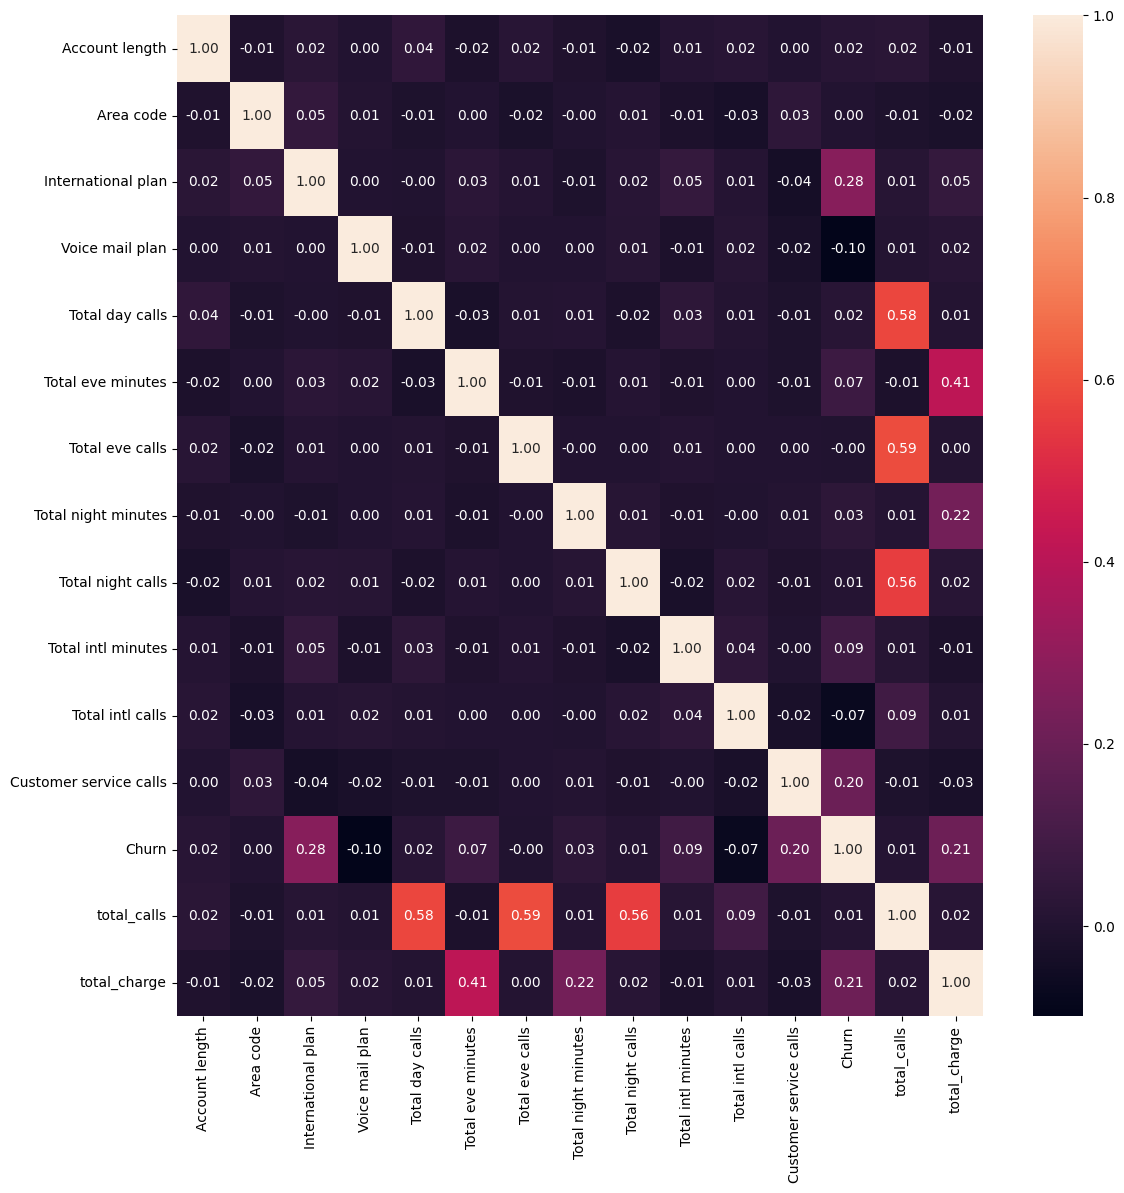

In [11]:
#checking multicollinearity
plt.figure(figsize=(13,13))
sns.heatmap(train.select_dtypes([int,float]).corr(),annot=True,fmt='0.2f')

* No multicollinearty present